In [127]:
# Imports
import sys
import os
sys.path.append(os.path.abspath('../..'))


from controller.marl.main import setup
from controller.marl.core.config import Config
from controller.marl.runners.sim_runner import run_sim


from project_paths import PROJECT_ROOT, FIGURES_DIR


import torch
from controller.marl.core.datasets import ObsData
from torch.utils.data import DataLoader


from notebooks.plt_style import set_style
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

from tqdm import tqdm

set_style()

In [128]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [129]:
config = Config.from_yaml(PROJECT_ROOT / "configs")
assert config.training.seed != -1
# assert config.comms.communication_type.value == "AIM", f"Comm type is {config.comms.communication_type}, should be aim"
# assert config.comms.autoencoder_type != "hq-vae"

In [130]:
CODEBOOK = 0

In [131]:
system, config = setup(config, device, load_agent_architecture=True)
config.training.simulation_timesteps = 11

Successfully loaded optimiser states.
Loaded checkpoint from step 30000


In [132]:
actor = system["actor"]
actor.eval()
print("Loaded")

Loaded


In [133]:
obs_logs_file = "./temp.csv"

In [134]:
run_sim(system, config, device, 6, collect_obs_file=obs_logs_file)

Running Simulation: 100%|██████████| 6/6 [00:01<00:00,  3.16it/s]


Exporting Buffer to ./temp.csv...
Done!


np.float32(0.13664103)

In [135]:
GO = system["sim"].get_global_obs_dim()
T = config.training.simulation_timesteps
W = config.training.worlds_parallised
N = system["sim"].get_num_agents()
mask = torch.tensor(system["sim"].get_agent_external_obs_mask(0), dtype=torch.bool, device=device)
dataset = ObsData(obs_logs_file, GO, T, W, N, device)

dataloader = DataLoader(dataset, batch_size=config.aim_training.aim_batch_size)

Loading CSV from ./temp.csv...
Final dataset shape ready for Dataloader: (5760, 11, 2, 294)


In [136]:
possible_targets = config.simulation.arena_width * config.simulation.arena_height
co_occurrence_matrix = np.zeros((config.comms.vocab_size, possible_targets))

for batch_obs, batch_global_obs, batch_actions, batch_targets, batch_critic_values, batch_return_values in dataloader:
    
    batch_obs = batch_obs.to(device)
    batch_targets = batch_targets.to(device).float()

    norm_x = batch_targets[..., 0].flatten().cpu().numpy()
    norm_y = batch_targets[..., 1].flatten().cpu().numpy()
        
    B = batch_obs.shape[0]
    O = batch_obs.shape[3]
    NC = config.comms.num_comms
    C = config.comms.communication_size
    
    actor_hidden_states = actor.init_hidden(batch_size=B)
    
    comms = torch.zeros((B, T, N, NC, C), dtype=torch.float32, device=device)
    
    action_logits, lstm_output, _ = actor(batch_obs, actor_hidden_states, comms)

    lstm_output_flat = lstm_output.contiguous().view(B * T, 1, N, -1)
    _, to_save, _ = actor.comm_protocol.get_comms_during_rollout(lstm_output_flat)
    
    codes = to_save[..., CODEBOOK].flatten().cpu().numpy().astype(int)
    
    norm_x = batch_targets[..., 0].flatten().cpu().numpy()
    norm_y = batch_targets[..., 1].flatten().cpu().numpy()
    
    disc_x = np.round(norm_x * config.simulation.arena_width).astype(int)
    disc_y = np.round(norm_y * config.simulation.arena_height).astype(int)
    
    target_ids = (disc_y * config.simulation.arena_width) + disc_x

    for code, target in zip(codes, target_ids):
        co_occurrence_matrix[code, target] += 1

In [137]:
code_usage_sums = co_occurrence_matrix.sum(axis=1)
active_code_indices = np.where(code_usage_sums > 100)[0] 

filtered_matrix = co_occurrence_matrix[active_code_indices]

row_sums = filtered_matrix.sum(axis=1, keepdims=True)
normalized_matrix = np.divide(filtered_matrix, row_sums, out=np.zeros_like(filtered_matrix), where=row_sums != 0)


target_labels = [f"Target ({i % config.simulation.arena_width}, {i // config.simulation.arena_height})" for i in range(possible_targets)] 
code_labels = [f"Code {i}" for i in active_code_indices]

df = pd.DataFrame(normalized_matrix, index=code_labels, columns=target_labels)

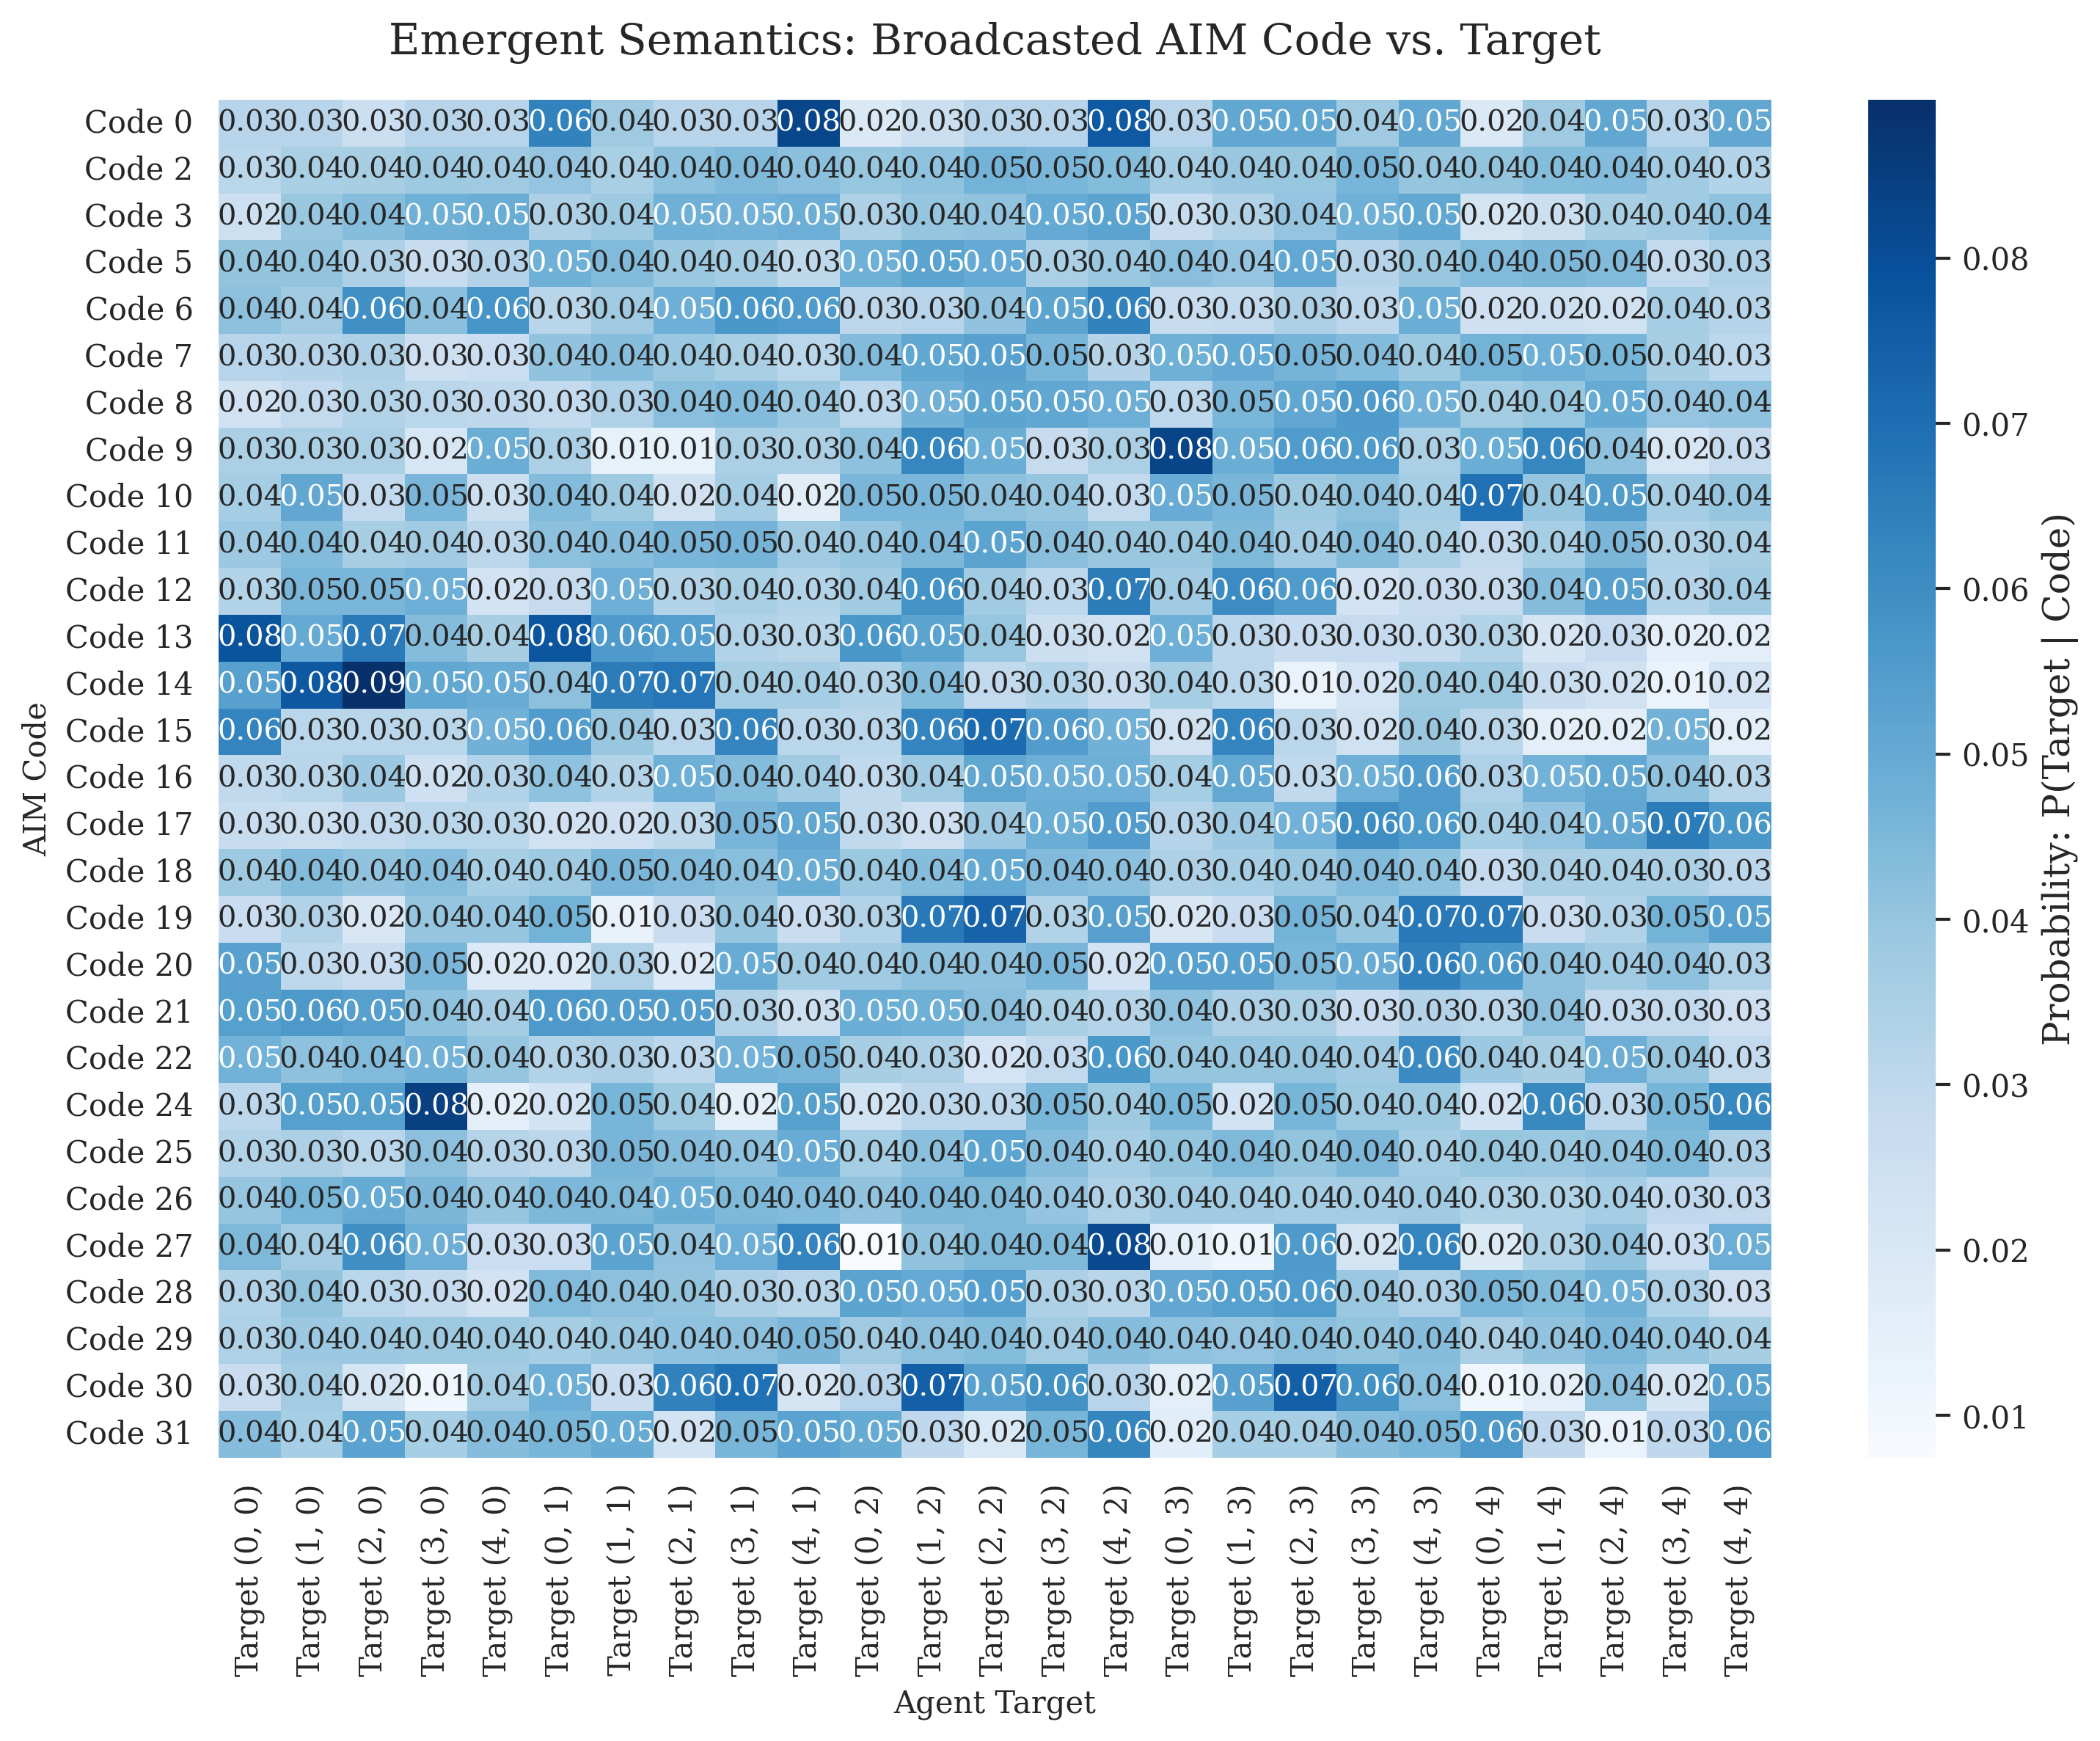

In [138]:
plt.figure(figsize=(10, 8))
sns.heatmap(df, annot=True, cmap="Blues", fmt=".2f", cbar_kws={'label': 'Probability: P(Target | Code)'})

plt.title("Emergent Semantics: Broadcasted AIM Code vs. Target", fontsize=14, pad=15)
plt.xlabel("Agent Target", fontsize=10)
plt.ylabel("AIM Code", fontsize=10)
plt.yticks(rotation=0) 

plt.tight_layout()
plt.show()

In [139]:
possible_targets = config.simulation.arena_width * config.simulation.arena_height
co_occurrence_matrix = np.zeros((possible_targets, config.comms.vocab_size))

for batch_obs, batch_global_obs, batch_actions, batch_targets, batch_critic_values, batch_return_values in dataloader:
    
    batch_obs = batch_obs.to(device)
    batch_targets = batch_targets.to(device).float()

    B = batch_obs.shape[0]
    NC = config.comms.num_comms
    C = config.comms.communication_size
    
    actor_hidden_states = actor.init_hidden(batch_size=B)
    comms = torch.zeros((B, T, N, NC, C), dtype=torch.float32, device=device)
    
    action_logits, lstm_output, _ = actor(batch_obs, actor_hidden_states, comms)

    lstm_output_flat = lstm_output.contiguous().view(B * T, 1, N, -1)
    _, to_save, _ = actor.comm_protocol.get_comms_during_rollout(lstm_output_flat)
    
    codes = to_save[..., CODEBOOK].flatten().cpu().numpy().astype(int)
    
    other_batch_targets = torch.roll(batch_targets, shifts=1, dims=2)
    
    norm_x = other_batch_targets[..., 0].flatten().cpu().numpy()
    norm_y = other_batch_targets[..., 1].flatten().cpu().numpy()
    
    disc_x = np.round(norm_x * config.simulation.arena_width).astype(int)
    disc_y = np.round(norm_y * config.simulation.arena_height).astype(int)
    
    other_target_ids = (disc_y * config.simulation.arena_width) + disc_x

    for code, other_target in zip(codes, other_target_ids):
        co_occurrence_matrix[other_target, code] += 1

code_usage_sums = co_occurrence_matrix.sum(axis=0)
active_code_indices = np.where(code_usage_sums > 100)[0] 

target_usage_sums = co_occurrence_matrix.sum(axis=1)
active_target_indices = np.where(target_usage_sums > 10)[0] 

filtered_matrix = co_occurrence_matrix[active_target_indices][:, active_code_indices]

row_sums = filtered_matrix.sum(axis=1, keepdims=True)
normalised_matrix = np.divide(filtered_matrix, row_sums, out=np.zeros_like(filtered_matrix), where=row_sums != 0)

target_labels = [f"Other Target ({i % config.simulation.arena_width}, {i // config.simulation.arena_height})" for i in active_target_indices] 
code_labels = [f"Code {i}" for i in active_code_indices]

df = pd.DataFrame(normalised_matrix, index=target_labels, columns=code_labels)

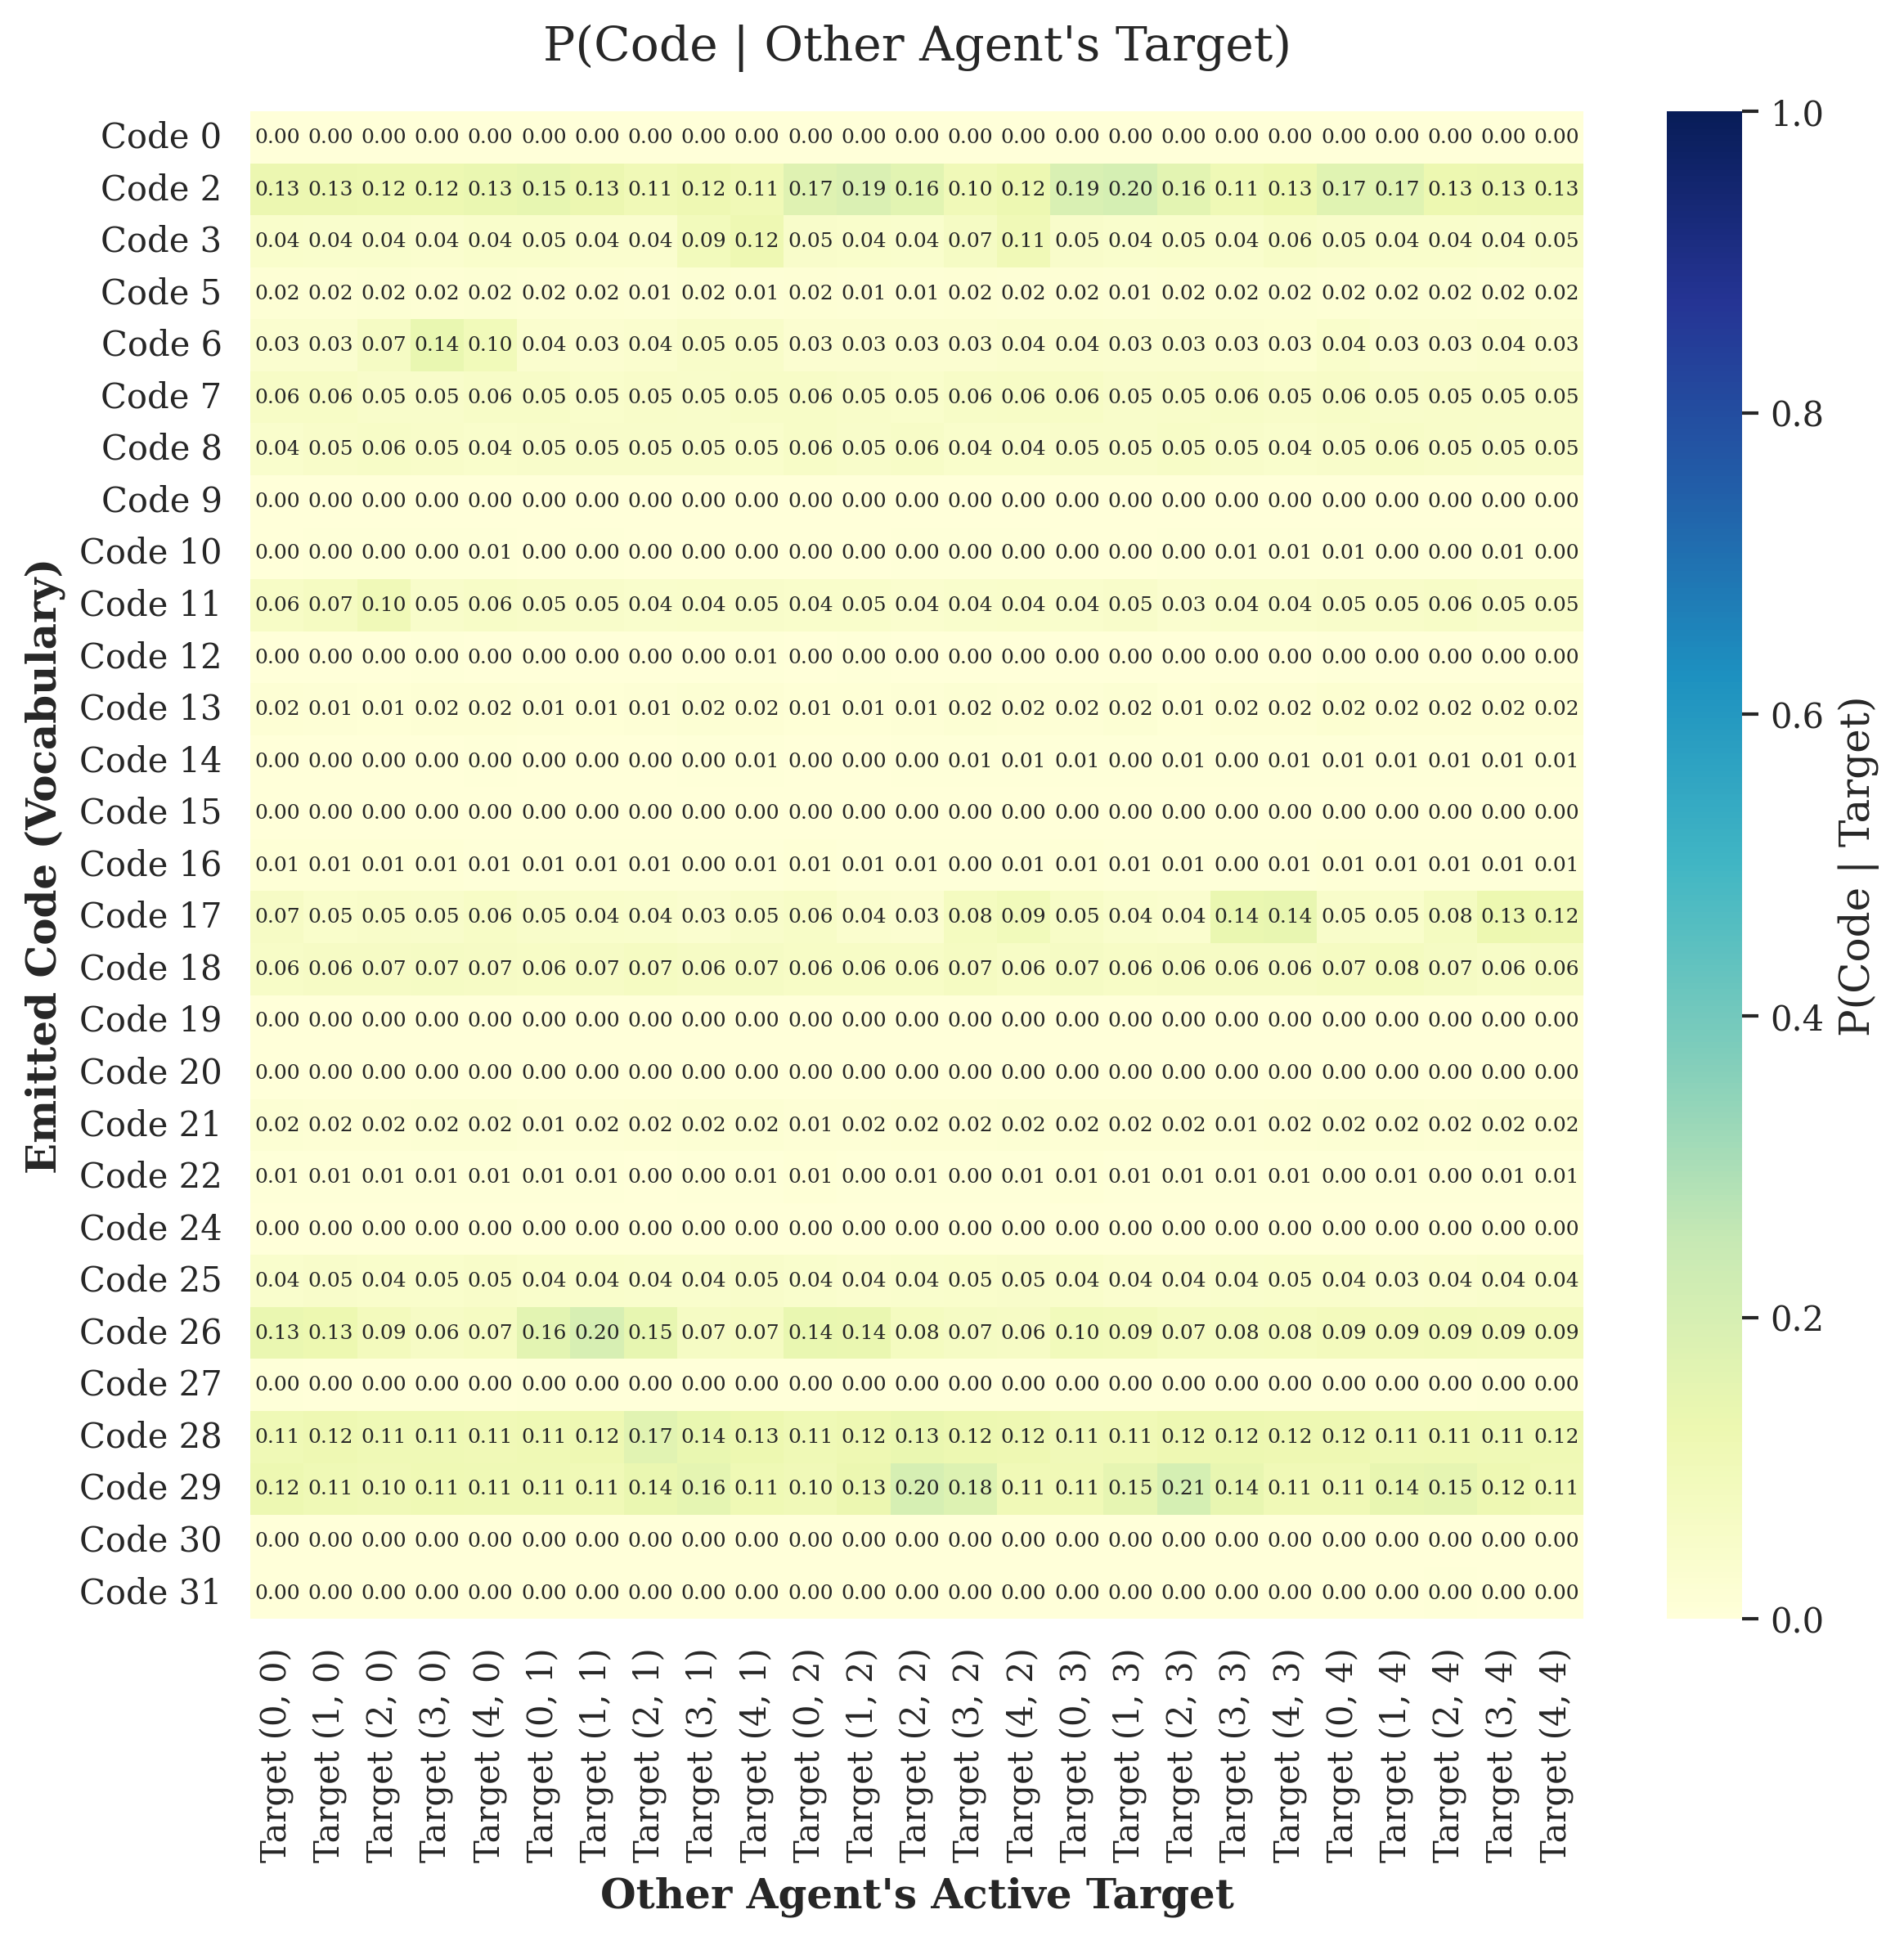

In [140]:
target_labels = [f"Target ({i % config.simulation.arena_width}, {i // config.simulation.arena_height})" for i in active_target_indices] 
code_labels = [f"Code {i}" for i in active_code_indices]

df = pd.DataFrame(normalised_matrix, index=target_labels, columns=code_labels)
plot_matrix = df.T

active_code_frequencies = co_occurrence_matrix[active_target_indices][:, active_code_indices].sum(axis=0)


fig_height = max(8.0, len(plot_matrix) * 0.2) 
plt.figure(figsize=(8, fig_height)) 

sns.heatmap(plot_matrix, annot=True, cmap="YlGnBu", vmin=0.0, vmax=1.0, fmt=".2f", annot_kws={"size": 6}, cbar_kws={'label': 'P(Code | Target)'})

plt.title(f"P(Code | Other Agent's Target)", fontsize=14, pad=15)
plt.xlabel("Other Agent's Active Target", fontsize=12, fontweight='bold')
plt.ylabel("Emitted Code (Vocabulary)", fontsize=12, fontweight='bold')

plt.yticks(fontsize=10, rotation=0) 
plt.xticks(fontsize=10)

plt.tight_layout()
plt.show()

In [141]:
possible_targets = config.simulation.arena_width * config.simulation.arena_height

temporal_matrix = np.zeros((T, config.comms.vocab_size, possible_targets))

for batch_obs, batch_global_obs, batch_actions, batch_targets, batch_critic_values, batch_return_values in dataloader:

    batch_obs = batch_obs.to(device)
    batch_targets = batch_targets.to(device).float()

    B = batch_obs.shape[0]
    NC = config.comms.num_comms
    C = config.comms.communication_size
    
    actor_hidden_states = actor.init_hidden(batch_size=B)
    comms = torch.zeros((B, T, N, NC, C), dtype=torch.float32, device=device)
    
    action_logits, lstm_output, _ = actor(batch_obs, actor_hidden_states, comms)

    lstm_output_flat = lstm_output.contiguous().view(B * T, 1, N, -1)
    _, to_save, _ = actor.comm_protocol.get_comms_during_rollout(lstm_output_flat)
    
    code_indices = to_save[..., CODEBOOK].view(B, T, N).cpu().numpy().astype(int)
    
    norm_x = batch_targets[..., 0].cpu().numpy()
    norm_y = batch_targets[..., 1].cpu().numpy()
    
    disc_x = np.round(norm_x * config.simulation.arena_width).astype(int)
    disc_y = np.round(norm_y * config.simulation.arena_height).astype(int)
    
    target_ids = (disc_y * config.simulation.arena_width) + disc_x

    for t in range(T):
        codes_t = code_indices[:, t, :].flatten()
        targets_t = target_ids[:, t, :].flatten()

        for code, target in zip(codes_t, targets_t):
            temporal_matrix[t, code, target] += 1

global_code_usage = temporal_matrix.sum(axis=(0, 2))
top_code_indices = np.sort(np.argsort(global_code_usage)[-7:])

temporal_matrix_filtered = temporal_matrix[:, top_code_indices, :]

100%|██████████| 7/7 [00:00<00:00, 421.36it/s]


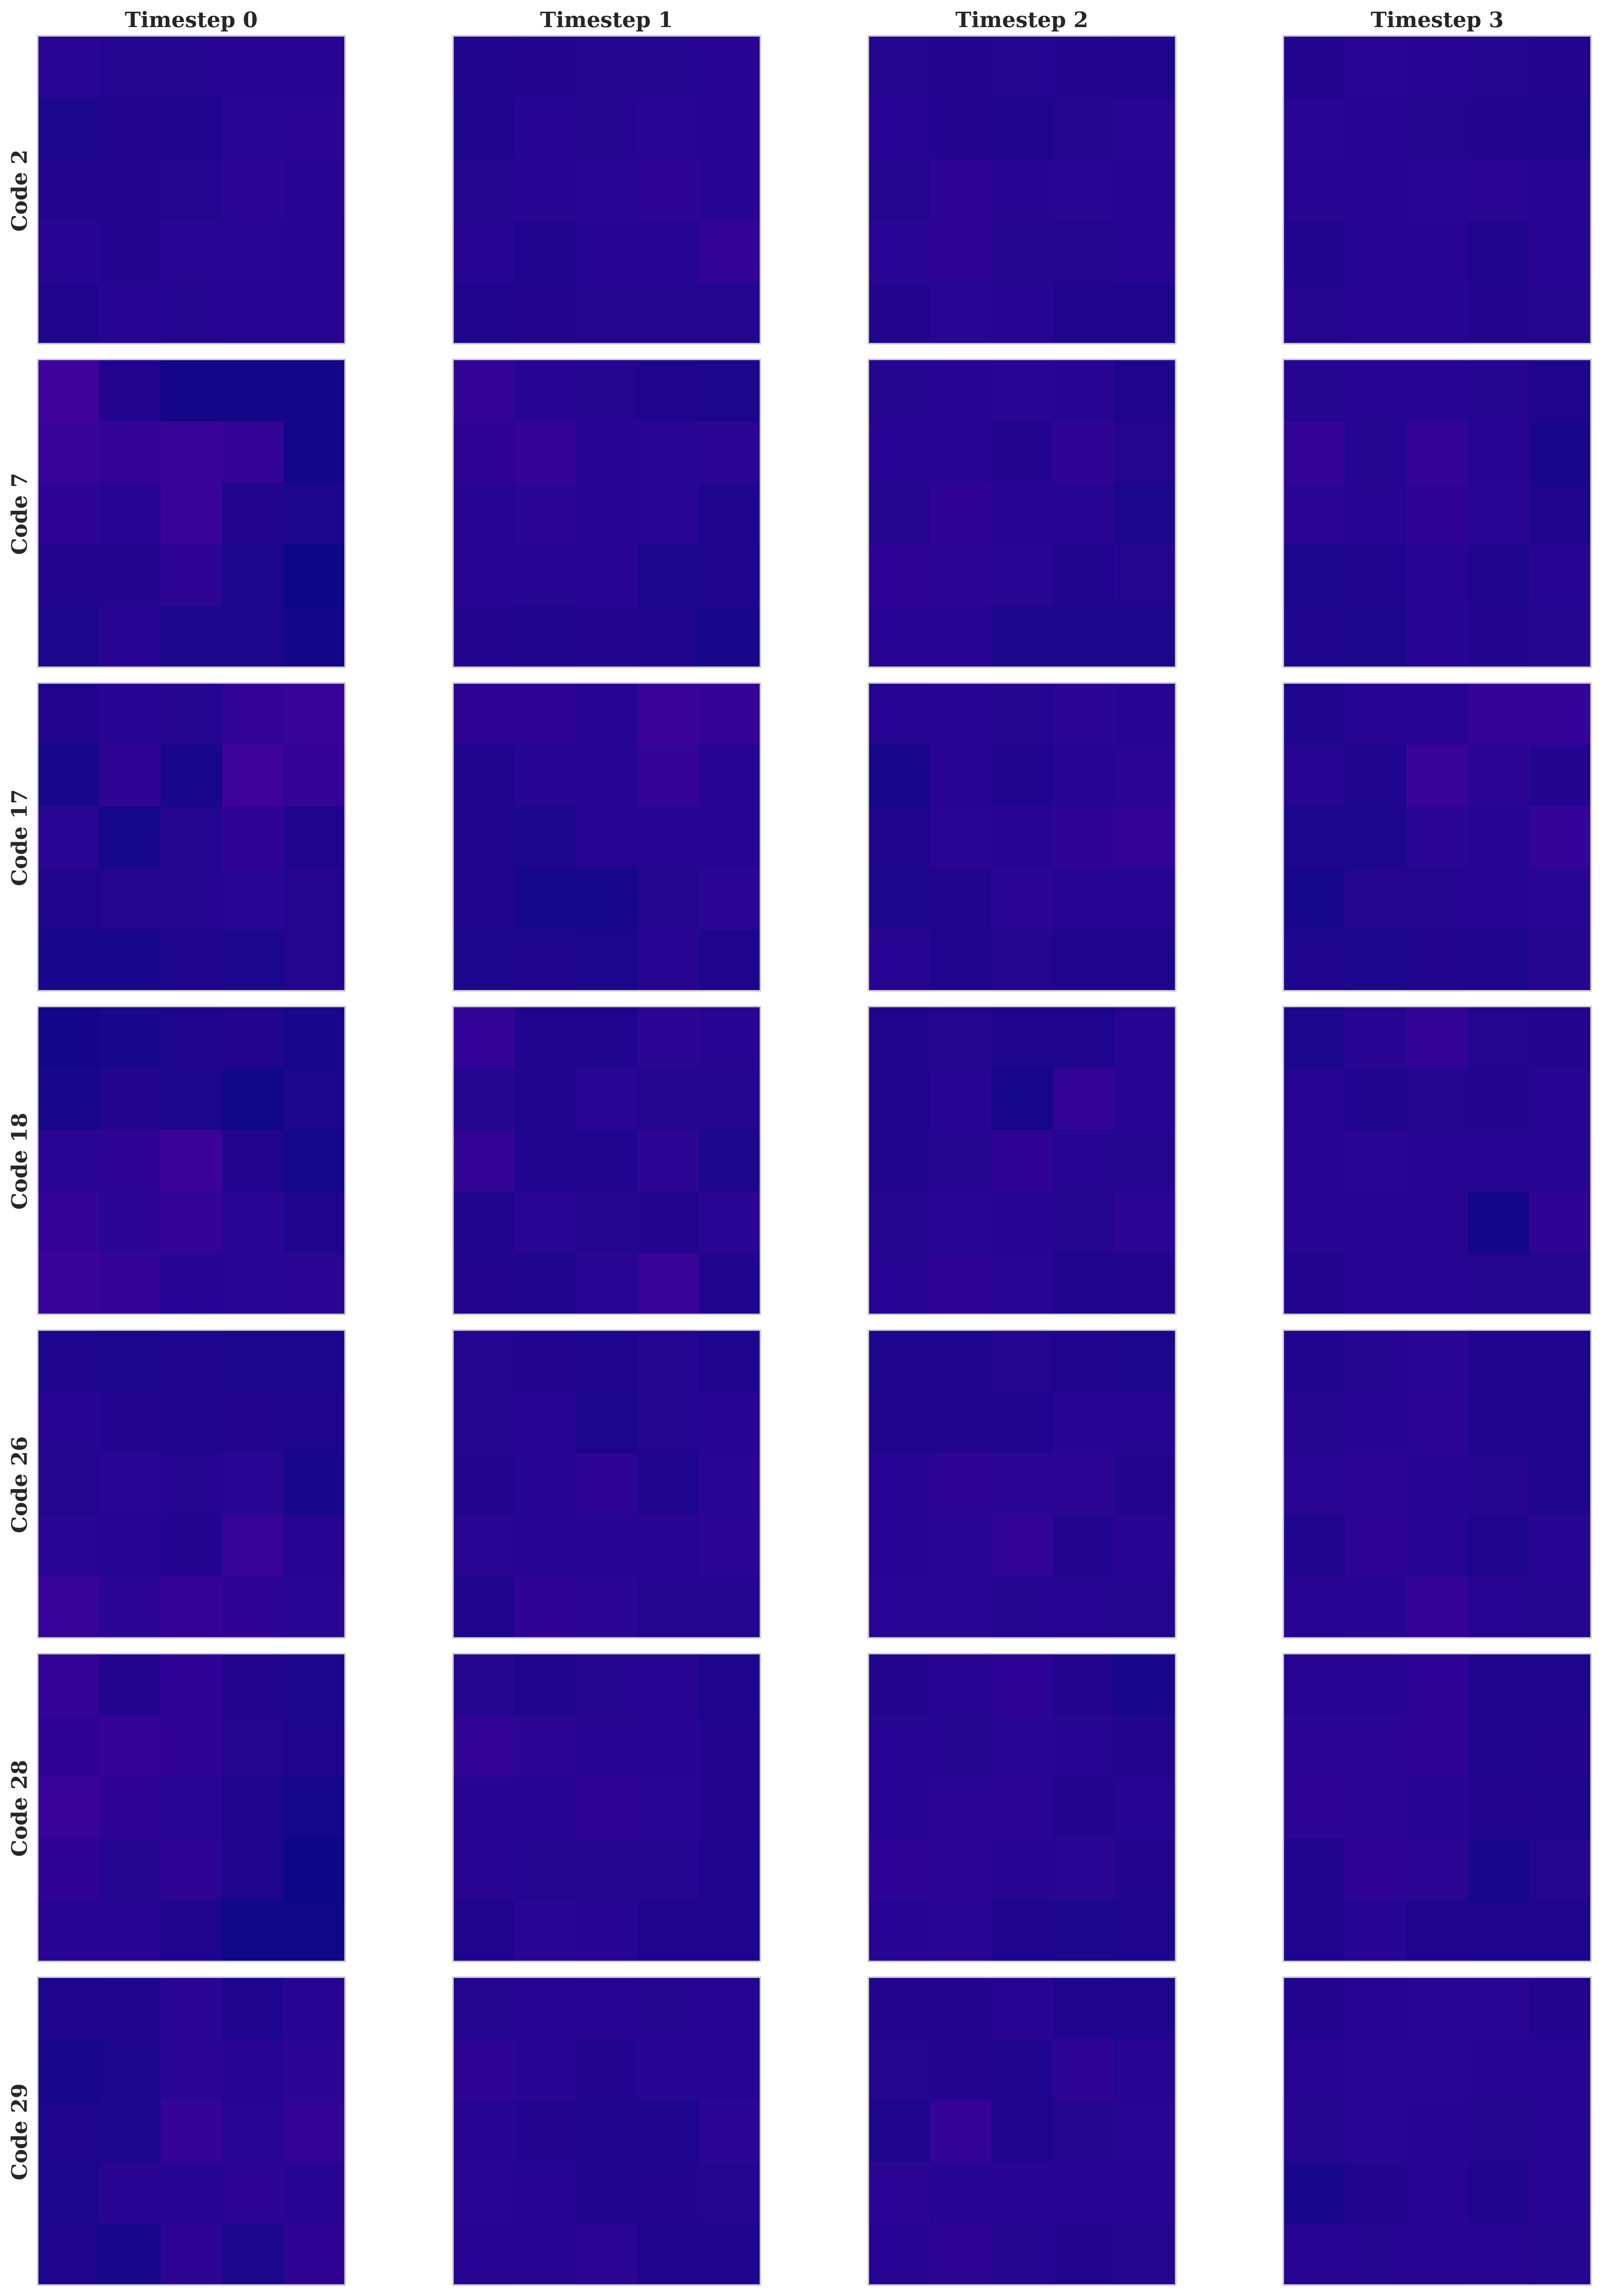

In [142]:
keyframes = [0, 1, 2, 3]#[0, 1, 2, 3, 4, 5]
num_codes = len(top_code_indices)

fig, axes = plt.subplots(
    num_codes, len(keyframes),
    figsize=(4 * len(keyframes), 3 * num_codes)
)

if num_codes == 1:
    axes = np.expand_dims(axes, axis=0)

tm = temporal_matrix_filtered.astype(np.float32, copy=True)
totals = tm.sum(axis=2, keepdims=True)
np.divide(tm, totals, out=tm, where=(totals != 0))

for row_idx, code_idx in tqdm(enumerate(top_code_indices), total=num_codes):
    for col_idx, t in enumerate(keyframes):
        ax = axes[row_idx, col_idx]

        target_dist_2d = tm[t, row_idx].reshape(config.simulation.arena_width, config.simulation.arena_height)

        im = ax.imshow(target_dist_2d, cmap="plasma", vmin=0.0, vmax=1.0, origin="lower", interpolation="nearest", aspect="equal")

        if row_idx == 0:
            ax.set_title(f"Timestep {t}", fontsize=14, fontweight="bold")
        if col_idx == 0:
            ax.set_ylabel(f"Code {code_idx}", fontsize=14, fontweight="bold")

        ax.set_xticks([])
        ax.set_yticks([])

plt.tight_layout()
# if input("Save to figures? (y/N): ") == "y":
#     plt.savefig(FIGURES_DIR / "own-target-given-code.png")
plt.show()

In [143]:
possible_targets = config.simulation.arena_width * config.simulation.arena_width

temporal_matrix = np.zeros((T, config.comms.vocab_size, possible_targets))

for batch_obs, batch_global_obs, batch_actions, batch_targets, batch_critic_values, batch_return_values in dataloader:

    batch_obs = batch_obs.to(device)
    batch_targets = batch_targets.to(device).float()

    B = batch_obs.shape[0]
    NC = config.comms.num_comms
    C = config.comms.communication_size
    
    actor_hidden_states = actor.init_hidden(batch_size=B)
    comms = torch.zeros((B, T, N, NC, C), dtype=torch.float32, device=device)
    
    action_logits, lstm_output, _ = actor(batch_obs, actor_hidden_states, comms)

    lstm_output_flat = lstm_output.contiguous().view(B * T, 1, N, -1)
    _, to_save, _ = actor.comm_protocol.get_comms_during_rollout(lstm_output_flat)
    
    code_indices = to_save[..., CODEBOOK].view(B, T, N).cpu().numpy().astype(int)
    
    norm_x = batch_targets[..., 0].cpu().numpy()
    norm_y = batch_targets[..., 1].cpu().numpy()
    
    disc_x = np.round(norm_x * config.simulation.arena_width).astype(int)
    disc_y = np.round(norm_y * config.simulation.arena_height).astype(int)
    
    target_ids = (disc_y * config.simulation.arena_width) + disc_x

    other_agent_target_ids = np.roll(target_ids, shift=1, axis=2)

    for t in range(T):

        codes_t = code_indices[:, t, :].flatten()
        targets_t = other_agent_target_ids[:, t, :].flatten()

        # Mask to only view when 1 target is active
        # obs_mask_t = (batch_obs[:, t, :, 12] == 1).cpu().numpy().flatten()

        # codes_t = codes_t[obs_mask_t]
        # targets_t = targets_t[obs_mask_t]

        for code, target in zip(codes_t, targets_t):
            temporal_matrix[t, code, target] += 1

global_code_usage = temporal_matrix.sum(axis=(0, 2))
top_code_indices = np.sort(np.argsort(global_code_usage)[-4:])
# top_code_indices = [29, 24, 15]

temporal_matrix_filtered = temporal_matrix[:, top_code_indices, :]

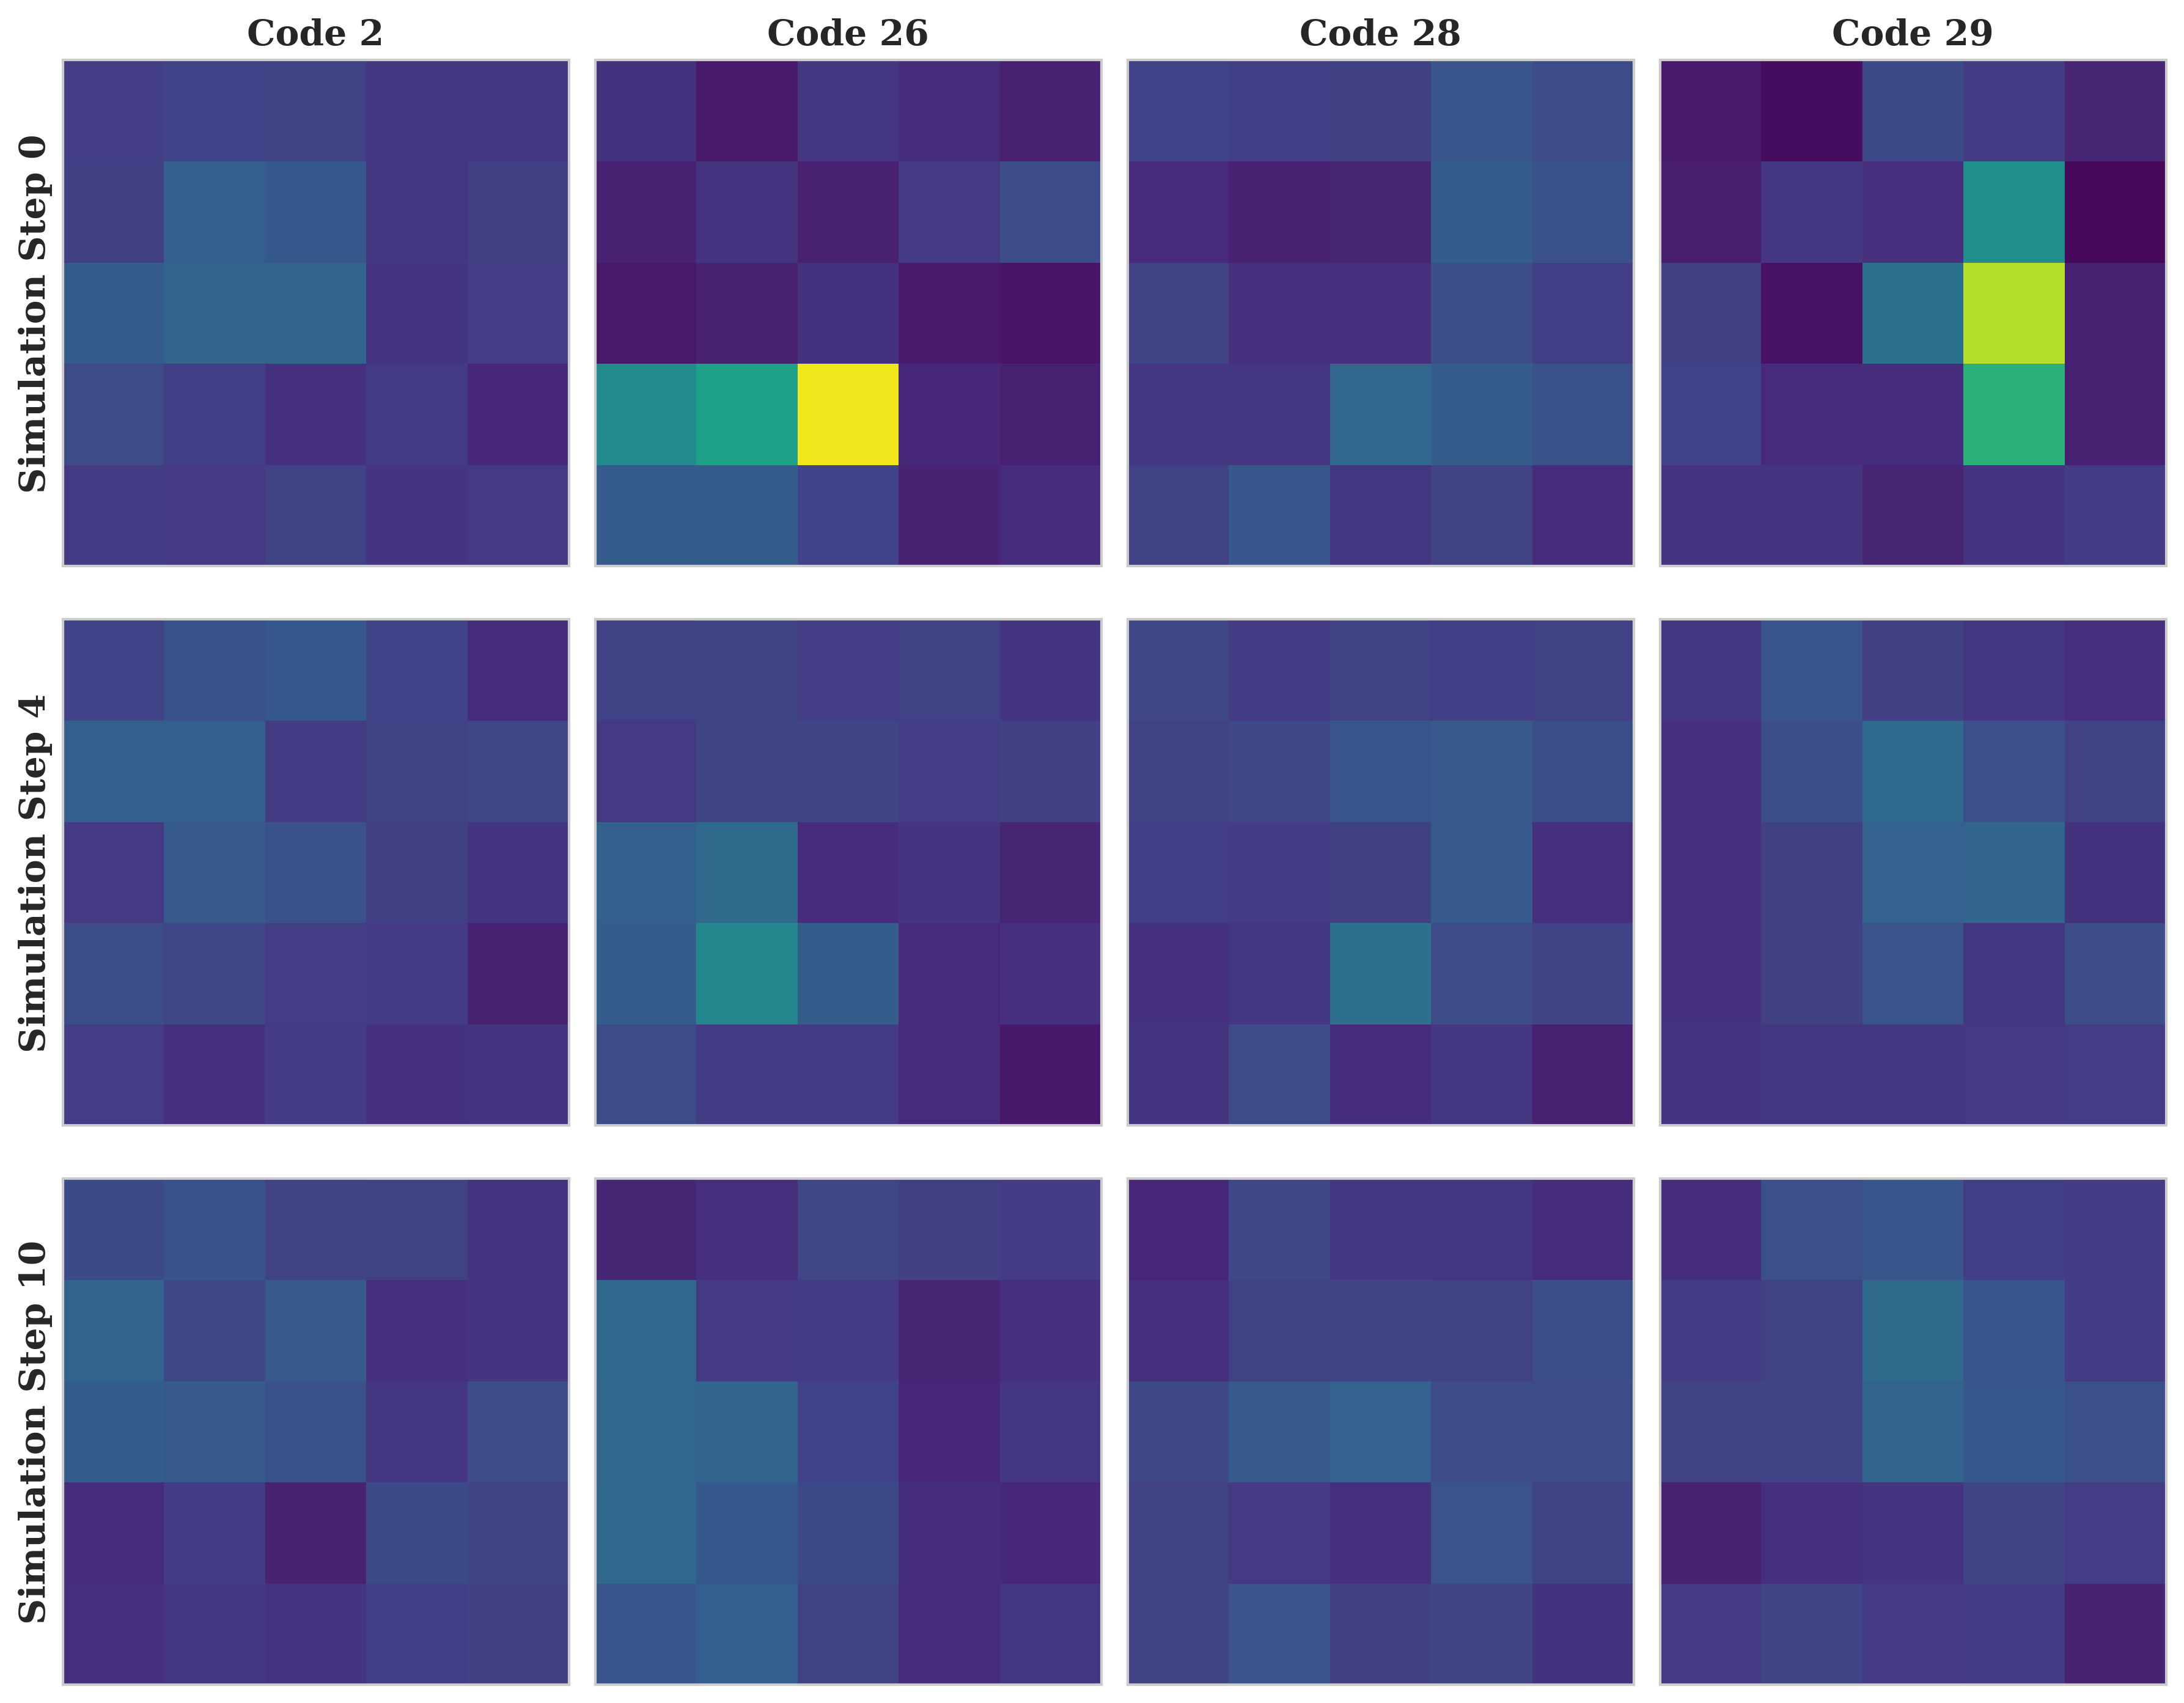

In [145]:
keyframes = [0, 4, 10]
num_codes = len(top_code_indices)

fig, axes = plt.subplots(
    len(keyframes), num_codes,
    figsize=(3 * num_codes, 3.2 * len(keyframes)),
    squeeze=False
)

tm = temporal_matrix_filtered.astype(np.float32, copy=True)
totals = tm.sum(axis=2, keepdims=True)
np.divide(tm, totals, out=tm, where=(totals != 0))

for row_idx, t in enumerate(keyframes):
    for col_idx, code_idx in enumerate(top_code_indices):
        ax = axes[row_idx, col_idx]

        target_dist_2d = tm[t, col_idx].reshape(
            config.simulation.arena_width,
            config.simulation.arena_height
        )

        im = ax.imshow(
            target_dist_2d,
            # cmap="cividis",
            cmap="viridis",
            vmin=0.0,
            vmax=0.2,
            origin="lower",
            interpolation="nearest",
            aspect="equal"
        )

        if row_idx == 0:
            ax.set_title(f"Code {code_idx}", fontsize=14, fontweight="bold")
        if col_idx == 0:
            ax.set_ylabel(f"Simulation Step {t}", fontsize=14, fontweight="bold")

        ax.set_xticks([])
        ax.set_yticks([])

plt.tight_layout()
# plt.savefig(FIGURES_DIR / "partner-target-given-code.png", dpi=600)
# plt.savefig(FIGURES_DIR / "partner-target-given-code-better.png", dpi=600)
plt.show()